In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, classification_report, confusion_matrix)
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
import warnings 
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.sans-serif']=['SimHei']
rand_seed = 67

In [2]:
df = pd.read_csv("F:\\album\\student_health\\AI_SocialMedia_Student_Health_Dataset_clean.csv")


df.drop(columns='Student_ID',inplace=True)
label = LabelEncoder()
df['Gender_enc'] = label.fit_transform(df['Gender'])
df['Education_Level_enc'] = label.fit_transform(df['Education_Level'])
df['Burnout_Level_enc'] = label.fit_transform(df['Burnout_Level'])
df.drop(columns=['Gender','Education_Level','Burnout_Level'],inplace=True)
display(df.head())

object_features = 'Academic_Failure_Risk'
x = df.drop(columns=object_features)
y = df[object_features]


,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Academic_Performance_Score,Academic_Failure_Risk,Gender_enc,Education_Level_enc,Burnout_Level_enc
0,19,5.32,1.21,7.30,1.41,74.06,98.90,4.05,88.80,0,1,0,1
1,16,5.21,3.89,7.81,2.48,76.13,89.94,4.65,50.60,0,2,1,2
2,25,3.61,2.65,6.34,0.06,65.01,76.75,5.28,96.67,0,1,2,1
3,23,2.93,1.43,6.12,1.37,74.67,87.38,3.66,85.65,0,1,2,1
4,20,6.52,1.64,5.23,1.14,67.74,88.04,3.25,71.84,0,2,0,2


In [3]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=rand_seed, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print("训练集样本数:", X_train.shape[0])
print("测试集样本数:", X_test.shape[0])
print("训练集高风险比例: {:.2%}".format(y_train.mean()))
print("测试集高风险比例: {:.2%}".format(y_test.mean()))

训练集样本数: 12000
测试集样本数: 3000
训练集高风险比例: 6.00%
测试集高风险比例: 6.00%


In [4]:

# 模型使用
models = {
    'Logistic Regression':LogisticRegression(class_weight='balanced',max_iter=1000,random_state=rand_seed),
    'Decision Tree':DecisionTreeClassifier(class_weight='balanced',max_depth=12,random_state=rand_seed),
    'Random Froest':RandomForestClassifier(class_weight='balanced',n_estimators=100,max_depth=10,random_state=rand_seed,n_jobs=-1),
    'XGBoost':xgb.XGBClassifier(scale_pos_wright = ((y_train == 0).sum()/(y_train == 1).sum()), use_label_encoder = False, eval_metric = 'logloss',random_state = rand_seed),
    'LightGBM':lgb.LGBMClassifier(class_weight='balanced',n_estimators=100,random_state=rand_seed, verbose = -1)   
}
results = []

In [5]:
def evaluate_model(model, X_train_data, X_test_data, y_train_data, y_test_data,model_name):
    model.fit(X_train_data,y_train_data)
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    return{
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC': auc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

In [6]:
for name, model in models.items():
    if name in ['Logistic Regression']:
        res = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    else:
        res = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    results.append(res)

In [7]:
results_df = pd.DataFrame(results)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']]
print(results_df.round(4).to_string(index=False))
best_model_name = results_df.loc[results_df['AUC'].idxmax(), 'Model']
print(f"\n最佳模型（按AUC）: {best_model_name}")

              Model  Accuracy  Precision  Recall  F1-score    AUC
Logistic Regression    0.8733     0.3069  0.8833    0.4556 0.9521
      Decision Tree    0.9980     0.9728  0.9944    0.9835 0.9963
      Random Froest    0.9940     0.9219  0.9833    0.9516 0.9994
            XGBoost    0.9977     0.9779  0.9833    0.9806 0.9999
           LightGBM    0.9987     0.9889  0.9889    0.9889 1.0000

最佳模型（按AUC）: LightGBM


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2820
           1       0.99      0.99      0.99       180

    accuracy                           1.00      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       1.00      1.00      1.00      3000



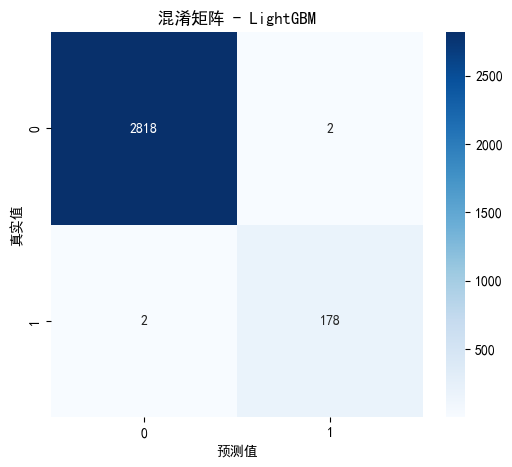

In [8]:
#输出以AUC为指标的最佳模型的详细报告
best_idx = results_df['AUC'].idxmax()
best_res = results[best_idx]
best_model = models[best_model_name]

print(classification_report(y_test, best_res['y_pred']))

cm = confusion_matrix(y_test, best_res['y_pred'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'混淆矩阵 - {best_model_name}')
plt.xlabel('预测值')
plt.ylabel('真实值')
plt.show()

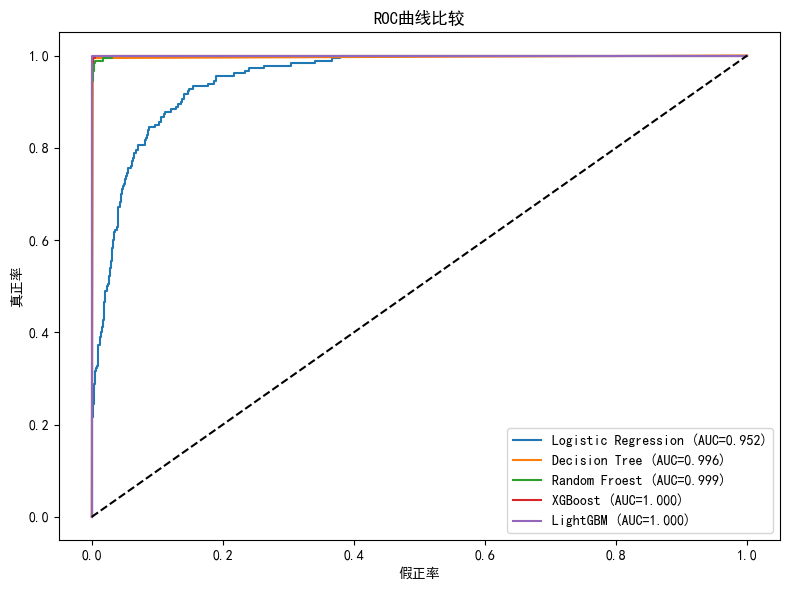

In [9]:
plt.figure(figsize=(8,6))
for res in results:
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        plt.plot(fpr, tpr, label=f"{res['Model']} (AUC={res['AUC']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('假正率')
plt.ylabel('真正率')
plt.title('ROC曲线比较')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

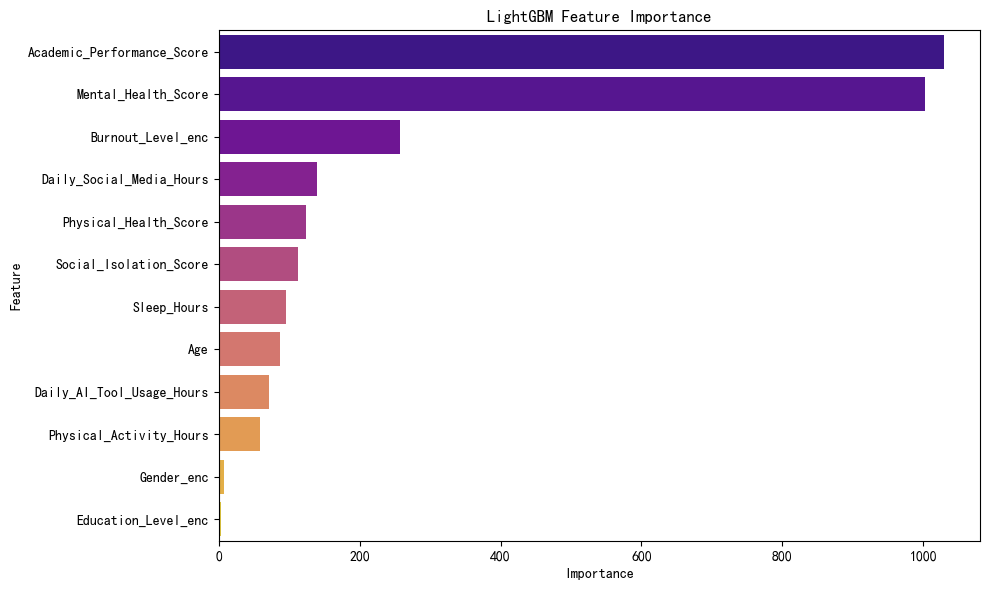

In [10]:
if 'LightGBM' in models:
    xgb_model = models['LightGBM']
    xgb_model.fit(X_train, y_train)
    xgb_imp = pd.DataFrame({
        'Feature': X_train.columns.tolist(),
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10,6))
    sns.barplot(data=xgb_imp, x='Importance', y='Feature', palette='plasma')
    plt.title('LightGBM Feature Importance')
    plt.tight_layout()
    plt.show()